# Benchmarks

## Initialize

In [1]:
#library(Rmisc)
library(dtplyr)
library(tidyverse)
library(glue)
library(arrow)
library(patchwork)
library(data.table)
library("jsonlite")
library(ggthemes)

Warning message:
“package ‘dtplyr’ was built under R version 4.0.5”
Warning message:
“package ‘tidyverse’ was built under R version 4.0.5”
── Attaching packages ─────────────────────────────────────── tidyverse 1.3.2 ──
✔ ggplot2 3.3.6      ✔ purrr   0.3.5 
✔ tibble  3.1.8      ✔ dplyr   1.0.10
✔ tidyr   1.2.1      ✔ stringr 1.5.0 
✔ readr   2.1.2      ✔ forcats 0.5.2 
Warning message:
“package ‘ggplot2’ was built under R version 4.0.5”
Warning message:
“package ‘tibble’ was built under R version 4.0.5”
Warning message:
“package ‘tidyr’ was built under R version 4.0.5”
Warning message:
“package ‘readr’ was built under R version 4.0.5”
Warning message:
“package ‘dplyr’ was built under R version 4.0.5”
Warning message:
“package ‘forcats’ was built under R version 4.0.5”
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
Warning message:
“package ‘glue’ was built under R version 4.0.

In [2]:
if (grepl("sc", Sys.info()[["nodename"]], fixed=TRUE)) {
    base_path = "/sc-projects/sc-proj-ukb-cvd"
} else {
    base_path = "/data/analysis/ag-reils/ag-reils-shared/cardioRS"}
print(base_path)

project_label="22_medical_records"
project_path = glue("{base_path}/results/projects/{project_label}")
figure_path = glue("{project_path}/figures")
output_path = glue("{project_path}/data")

experiment = 230425
experiment_path = glue("{output_path}/{experiment}")

[1] "/sc-projects/sc-proj-ukb-cvd"


In [3]:
library(data.table)
library(arrow)

In [4]:
endpoints_md = fread(glue("{experiment_path}/endpoints.csv"), colClasses=c("phecode"="character"))
endpoints = sort(endpoints_md$endpoint)

In [5]:
endpoint_defs = arrow::read_feather(glue("{output_path}/phecode_defs_220306.feather")) %>% arrange(endpoint)

In [6]:
endpoint_selection = c(
    
   'phecode_401', #  "Hypertension", # intervention
    'phecode_202', #  "Diabetes mellitus", # intervention
    'phecode_416-21', #  "Atrial fibrillation", # intervention
    'phecode_468', #  "Pneumonia", # intervention
    'phecode_474', #  "Chronic obstructive pulmonary disease [COPD]", # interventio
    'phecode_583', #  "Chronic kidney disease", # intervention
    
    'phecode_404', #  "Ischemic heart disease",
    'phecode_404-1', #  "Myocardial infarction [Heart attack]", # intervention
    'phecode_431-11', #  "Cerebral infarction [Ischemic stroke]",
    'phecode_424', #  "Heart failure", # intervention
    'phecode_420', #  "Cardiac arrest", # intervention
    'OMOP_4306655', #  "All-Cause Death", # intervention
    
    'phecode_438-11',   #  "Abdominal aortic aneurysm",
    'phecode_440-3',#  "Pulmonary embolism", # intervention
    'phecode_413-21',#  "Aortic stenosis", # intervention
    'phecode_413-11', #  "Mitral valve insufficiency",
    'phecode_410-2',#  "Endocarditis",
    'phecode_400',#  "Rheumatic fever and chronic rheumatic heart diseases",	
    
    'phecode_164', #  "Anemia", # intervention
    'phecode_718',  #  "Back pain", # intervention
    'phecode_324-11', #  "Parkinson's disease (Primary)",
    'phecode_705-1', #  "Rheumatoid arthritis", # NEW + interventio
    'phecode_665', #  "Psoriasis", # interesting
    'phecode_284'#  "Suicide ideation and attempt or self harm" # intervention
)

endpoints_common = c(
    'phecode_401', #  "Hypertension", # intervention
    'phecode_202', #  "Diabetes mellitus", # intervention
    'phecode_416-21', #  "Atrial fibrillation", # intervention
    'phecode_468', #  "Pneumonia", # intervention
    'phecode_474', #  "Chronic obstructive pulmonary disease [COPD]", # interventio
    'phecode_583', #  "Chronic kidney disease", # intervention
    
    'phecode_404', #  "Ischemic heart disease",
    'phecode_404-1', #  "Myocardial infarction [Heart attack]", # intervention
    'phecode_431-11', #  "Cerebral infarction [Ischemic stroke]",
    'phecode_424', #  "Heart failure", # intervention
    'phecode_420', #  "Cardiac arrest", # intervention
    'OMOP_4306655' #  "All-Cause Death", # intervention)
    )
    
endpoints_cardio = c(
    'phecode_438-11',   #  "Abdominal aortic aneurysm",
    'phecode_440-3',#  "Pulmonary embolism", # intervention
    'phecode_413-21',#  "Aortic stenosis", # intervention
    'phecode_413-11', #  "Mitral valve insufficiency",
    'phecode_410-2',#  "Endocarditis",
    'phecode_400'#  "Rheumatic fever and chronic rheumatic heart diseases",	
)

endpoints_interesting = c(
    'phecode_164', #  "Anemia", # intervention
    'phecode_718',  #  "Back pain", # intervention
    'phecode_324-11', #  "Parkinson's disease (Primary)",
    'phecode_705-1', #  "Rheumatoid arthritis", # NEW + interventio
    'phecode_665', #  "Psoriasis", # interesting
    'phecode_284'#  "Suicide ideation and attempt or self harm" # intervention
)

endpoint_defs = endpoint_defs %>% 
    mutate(name = phecode_string) %>%
    mutate(name = 
           case_when( 
               phecode_string == "Myocardial infarction [Heart attack]"~"Myocardial infarction",
               phecode_string == "Cerebral infarction [Ischemic stroke]"~"Ischemic stroke",
               phecode_string == "Chronic obstructive pulmonary disease [COPD]"~"Chronic obstructive pulmonary disease",
               phecode_string == "Mitral valve insufficiency"~"Mitral insufficiency",
               phecode_string == "Parkinson's disease (Primary)"~"Parkinson's disease",
               phecode_string == "Suicide ideation and attempt or self harm"~"Suicide attempt",
               phecode_string == "Ischemic heart disease"~"Ischemic heart disease",
               phecode_string == "Chronic kidney disease"~"Chronic kidney disease",
               phecode_string == "Rheumatic fever and chronic rheumatic heart diseases"~"Rheumatic heart disease",
               phecode_string == "Abdominal aortic aneurysm"~"Abdominal aortic aneurysm",
                  TRUE ~ name)
           )
            
endpoint_map = endpoint_defs$name
names(endpoint_map) =  endpoint_defs$endpoint
#endpoint_order = (endpoint_defs %>% arrange(as.numeric(phecode)))$endpoint
endpoint_order = endpoint_selection

In [7]:
endpoints_md %>% filter(endpoint %in% endpoint_selection) %>% as_tibble() %>% arrange(n)  %>%
    mutate(endpoint = recode(endpoint, !!!endpoint_map)) %>% mutate(perc = freq*100)

V1,endpoint,eligable,n,freq,phecode,phecode_string,phecode_category,sex,ICD10_only,phecode_top,leaf,perc
<int>,<chr>,<int>,<int>,<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>,<int>,<dbl>,<dbl>
976,Cardiac arrest,502105,2930,0.005835433,420,Cardiac arrest,Cardio,Both,0,420,1,0.5835433
918,Endocarditis,499427,3115,0.006237148,410.2,Endocarditis,Cardio,Both,0,410,1,0.6237148
1013,Abdominal aortic aneurysm,502088,3413,0.006797613,438.11,Abdominal aortic aneurysm,Cardio,Both,0,438,1,0.6797613
521,Parkinson's disease,501702,4196,0.008363531,324.11,Parkinson's disease (Primary),Neuro,Both,0,324,1,0.8363531
464,Suicide attempt,498884,5253,0.010529502,284,Suicide ideation and attempt or self harm,Mental,Both,0,284,0,1.0529502
929,Aortic stenosis,501283,6212,0.012392202,413.21,Aortic stenosis,Cardio,Both,0,413,1,1.2392202
1622,Rheumatoid arthritis,497765,7445,0.014956857,705.1,Rheumatoid arthritis,Musc/Skel,Both,0,705,0,1.4956857
925,Mitral insufficiency,500364,8343,0.016673861,413.11,Mitral valve insufficiency,Cardio,Both,0,413,1,1.6673861
1511,Psoriasis,488455,8701,0.017813309,665,Psoriasis,Derm,Both,0,665,0,1.7813309


In [8]:
eligable_eids = arrow::read_feather(glue("{output_path}/eligable_eids_long_220627.feather")) %>% 
    mutate(included = 1)
eligable_eids$eid = as.numeric(levels(eligable_eids$eid))[eligable_eids$eid]

Warning message:
“Coercing dictionary values to R character factor levels”


In [9]:
data_outcomes = arrow::read_feather(glue("{output_path}/baseline_outcomes_long_220627.feather", as_data_frame=FALSE)) 

In [10]:
partitions = 0:21
partitions
paths = c()
for (p in partitions){
    temp_path = glue("{experiment_path}/loghs/Identity(Records)+MLP/{p}/test.feather")
    paths = c(paths, temp_path)
    }

[1]  0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21

In [11]:
read_predictions = function(paths, endpoint_list){
    predictions = paths %>% map_df(
        ~suppressWarnings(read_feather(., col_select=c("eid", all_of(endpoint_list)))) %>% 
        pivot_longer(all_of(endpoint_list), names_to="endpoint", values_to="logh") %>%
        mutate(eid = as.integer(as.character(eid))) %>%
        select(endpoint, eid, logh))# %>% arrange(endpoint, eid)
    return(predictions)
    }

calc_ratios = function(pred_outcomes, endpoints_md){
    
    logh_inc = pred_outcomes %>% 
        filter(included==1) %>% 
        group_by(endpoint) %>% 
        mutate(logh_perc = ntile(logh, 10)) %>% 
        ungroup()

    logh_T_agg = logh_inc %>% group_by(endpoint, logh_perc) %>% summarise(n=sum(event, na.rm=TRUE), ratio = mean(event)) #%>% as_tibble()
    temp_ordered = logh_T_agg %>% mutate(endpoint = factor(endpoint, levels=endpoints_md$endpoint)) 
    temp_ratios = temp_ordered %>% #filter(logh_perc %in% c(1, 10)) %>% 
        pivot_wider(names_from=logh_perc, values_from=c(n, ratio)) %>% 
        mutate(ratio=ratio_10/ratio_1) %>%
        #mutate(endpoint_string = recode(endpoint, !!!endpoint_map)) %>%
        select(endpoint, starts_with("n_"), starts_with("ratio_"), ratio) %>%
        arrange(ratio) #%>% as_tibble()
    return(temp_ratios)
    }

In [12]:
prepare_ratios = function(endpoint_list){
    
    temp_outcomes = data_outcomes %>% filter(endpoint %in% endpoint_list)
    temp_eligability = eligable_eids %>% filter(endpoint %in% endpoint_list)
    temp_outcomes_eligability = temp_outcomes %>% left_join(temp_eligability, by=c("eid", "endpoint"))
    pred_outcomes = read_predictions(paths, endpoint_list) %>% left_join(temp_outcomes_eligability, on=c(eid, endpoint)) %>% as_tibble()
    temp_df = calc_ratios(pred_outcomes, endpoints_md)
    
    return(temp_df)
    }

In [13]:
ep_chunks = split(endpoints_md$endpoint, ceiling(seq_along(endpoints_md$endpoint)/500))

In [26]:
#library(furrr)
#library(future)
# Set the number of cores to be used for parallel processing
#plan(multicore(workers = 64))

In [27]:
#options(future.globals.maxSize = 60 * 1024^3)

In [28]:
#ratio_dfs <- future_map(ep_chunks, ~ prepare_ratios(data_outcomes %>% filter(endpoint %in% .x)))

In [14]:
ratio_dfs = c()
#i=1
for (i in 1:length(ep_chunks[])){
    endpoint_list = ep_chunks[[i]]
    ratio_dfs[[i]] = prepare_ratios(endpoint_list)
    print(ratio_dfs[[i]])
    flush.console()
}

Joining, by = c("endpoint", "eid")
`summarise()` has grouped output by 'endpoint'. You can override using the
`.groups` argument.


# A tibble: 500 × 22
# Groups:   endpoint [500]
   endpoint    n_1   n_2   n_3   n_4   n_5   n_6   n_7   n_8   n_9  n_10 ratio_1
   <fct>     <int> <int> <int> <int> <int> <int> <int> <int> <int> <int>   <dbl>
 1 phecode_…    18    10     9     9    12     8    16    13    15    17 3.58e-4
 2 phecode_…     8     6     9     8    18     4    15    11    13    13 1.59e-4
 3 phecode_…   137   107   130   135   130   166   166   180   191   223 5.04e-3
 4 phecode_…    12    15    17    15     7    16    18    19    21    24 5.25e-4
 5 phecode_…   325   331   364   369   361   434   403   450   506   672 1.22e-2
 6 phecode_…     7     2     9    10    18     5    18     7    13    15 1.39e-4
 7 phecode_…    71    69    55    69    64    80    86    94   106   160 2.64e-3
 8 phecode_…    42    52    48    64    63    60    89    65    76   110 8.36e-4
 9 phecode_…     7    10    16    15    17    22    24    18    24    19 2.56e-4
10 phecode_…     5    16    18    20    28    27    21    25 

Joining, by = c("endpoint", "eid")
`summarise()` has grouped output by 'endpoint'. You can override using the
`.groups` argument.


# A tibble: 500 × 22
# Groups:   endpoint [500]
   endpoint    n_1   n_2   n_3   n_4   n_5   n_6   n_7   n_8   n_9  n_10 ratio_1
   <fct>     <int> <int> <int> <int> <int> <int> <int> <int> <int> <int>   <dbl>
 1 phecode_…    20     5    14     8    28    24    19    23    21    41 3.98e-4
 2 phecode_…    20    21    22    16    24    25    21    33    34    46 3.98e-4
 3 phecode_…    12     8     4     8     8    13    19    10    21    30 2.39e-4
 4 phecode_…    10    17    15     7    13    14    13    18    23    28 1.99e-4
 5 phecode_…    11     7     7     3     9     7     8    14     9    31 2.19e-4
 6 phecode_…    21    20    20    20    26    26    33    40    53    63 4.19e-4
 7 phecode_…    30    22    30    29    33    47    38    52    61    91 5.97e-4
 8 phecode_…    21    14    21    14    19    22    19    23    21    65 4.18e-4
 9 phecode_…    19    17    14    26    29    35    25    36    30    60 3.79e-4
10 phecode_…   169   171   151   229   211   240   238   319 

Joining, by = c("endpoint", "eid")
`summarise()` has grouped output by 'endpoint'. You can override using the
`.groups` argument.


# A tibble: 500 × 22
# Groups:   endpoint [500]
   endpoint    n_1   n_2   n_3   n_4   n_5   n_6   n_7   n_8   n_9  n_10 ratio_1
   <fct>     <int> <int> <int> <int> <int> <int> <int> <int> <int> <int>   <dbl>
 1 phecode_…   223   222   242   288   290   293   315   373   381   424 4.48e-3
 2 phecode_…    18    19    14    26    27    39    26    20    28    36 6.60e-4
 3 phecode_…    65    58    57    72    94    56    82    86   115   151 2.39e-3
 4 phecode_…   425   323   303   405   444   511   527   631   737  1070 1.59e-2
 5 phecode_…   554   386   417   525   616   766   857   993  1226  1453 2.13e-2
 6 phecode_…    18    21    25    17    40    46    28    34    43    49 6.62e-4
 7 phecode_…    58    64    95   114   105   121   130   136   162   181 1.16e-3
 8 phecode_…   238   174   183   209   258   307   350   433   516   759 8.82e-3
 9 phecode_…   172   171   170   188   218   231   311   311   253   580 3.43e-3
10 phecode_…    50    67    80   117   101   112   122   142 

Joining, by = c("endpoint", "eid")
`summarise()` has grouped output by 'endpoint'. You can override using the
`.groups` argument.


# A tibble: 383 × 22
# Groups:   endpoint [383]
   endpoint    n_1   n_2   n_3   n_4   n_5   n_6   n_7   n_8   n_9  n_10 ratio_1
   <fct>     <int> <int> <int> <int> <int> <int> <int> <int> <int> <int>   <dbl>
 1 phecode_…     8     7     7    15    10    10     8    11    12    15 1.59e-4
 2 phecode_…    12    15    12    12    19    27    13    23    19    26 2.39e-4
 3 phecode_…     9    10     9     9    12     9    14    10    12    24 1.79e-4
 4 phecode_…    23    21    29    35    43    27    33    37    48    65 4.58e-4
 5 phecode_…    48    73    71    74    52    72    67   100   106   151 9.58e-4
 6 phecode_…     6     4    10     4    12    17     8    13    15    21 1.19e-4
 7 phecode_…     9     2     1     8     7    13     9    20    21    32 1.79e-4
 8 phecode_…    17    13    19    22    30    26    35    26    47    68 3.39e-4
 9 phecode_…     7    10     7    11    10    13    15    21    28    29 1.39e-4
10 phecode_…  4862  6119  8500  7614  8342  7565  9883 11581 

In [15]:
ratio_df_complete = bind_rows(ratio_dfs) %>% ungroup() %>%
    mutate(endpoint_string = recode(endpoint, !!!endpoint_map)) %>% 
    select(endpoint, endpoint_string, starts_with("n_"), starts_with("ratio_"), ratio) %>%
    arrange(ratio) %>% left_join(endpoints_md %>% select(endpoint, phecode_category) %>% as_tibble(), by="endpoint")

In [16]:
ratio_df_complete %>% write_feather("outputs/rateratios_230425.feather")
ratio_df_complete %>% write_csv("outputs/rateratios_230425.csv")

In [17]:
ratio_df_complete = arrow::read_feather("outputs/rateratios_230425.feather")

In [27]:
t = ratio_df_complete %>% filter(ratio>=10) %>% arrange(desc(ratio)) #%>% filter(!str_detect(endpoint, "-"))
print(nrow(t))
print(nrow(t)/nrow(ratio_df_complete))
t

[1] 1341
[1] 0.7121614


endpoint,endpoint_string,n_1,n_2,n_3,n_4,n_5,n_6,n_7,n_8,⋯,ratio_3,ratio_4,ratio_5,ratio_6,ratio_7,ratio_8,ratio_9,ratio_10,ratio,phecode_category
<chr>,<fct>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
phecode_057,Retrovirus,0,1,8,7,13,14,16,23,⋯,1.593530e-04,1.394339e-04,2.589487e-04,2.788734e-04,3.187124e-04,4.581491e-04,0.0006573443,0.0016334011,Inf,ID
phecode_057-1,Human immunodeficiency virus,0,1,8,6,9,15,18,19,⋯,1.593530e-04,1.195148e-04,1.792722e-04,2.987869e-04,3.585515e-04,3.784710e-04,0.0006374248,0.0016334011,Inf,ID
phecode_084-4,Trichomoniasis,0,0,0,3,7,2,26,65,⋯,0.000000e+00,5.994725e-05,1.398769e-04,3.996483e-05,5.195428e-04,1.298857e-03,0.0022380305,0.0032771161,Inf,ID
phecode_098-2,Carrier or suspected carrier of Staphylococcus aureus,0,3,6,6,9,5,14,16,⋯,1.194624e-04,1.194624e-04,1.791936e-04,9.955202e-05,2.787512e-04,3.185728e-04,0.0005176808,0.0013738452,Inf,ID
phecode_104-5,Gastrointestinal stromal tumor*,0,3,6,14,18,15,14,22,⋯,1.194149e-04,2.786347e-04,3.582446e-04,2.985372e-04,2.786347e-04,4.378632e-04,0.0006169891,0.0007165035,Inf,Neoplasms
phecode_142-2,Abnormal mammogram,0,0,0,1,0,13,27,38,⋯,0.000000e+00,1.991001e-05,0.000000e+00,2.588301e-04,5.375809e-04,7.565953e-04,0.0010751618,0.0010552514,Inf,Neoplasms
phecode_142-21,Mammographic microcalcification,0,0,0,1,0,13,28,37,⋯,0.000000e+00,1.991001e-05,0.000000e+00,2.588301e-04,5.574913e-04,7.366849e-04,0.0010751618,0.0010552514,Inf,Neoplasms
phecode_168-15,Acquired coagulation factor deficiency,0,2,1,1,0,2,5,6,⋯,1.990248e-05,1.990248e-05,0.000000e+00,3.980496e-05,9.951239e-05,1.194149e-04,0.0002985372,0.0014131041,Inf,Blood
phecode_168-211,Activated protein C resistance*,0,2,6,8,8,13,11,17,⋯,1.194386e-04,1.592547e-04,1.592547e-04,2.587889e-04,2.189752e-04,3.384162e-04,0.0002986025,0.0009953418,Inf,Blood


In [28]:
t = ratio_df_complete %>% filter(ratio>=100) %>% arrange(desc(ratio)) #%>% filter(!str_detect(endpoint, "-"))
print(nrow(t))
print(nrow(t)/nrow(ratio_df_complete))
t

[1] 230
[1] 0.1221455


endpoint,endpoint_string,n_1,n_2,n_3,n_4,n_5,n_6,n_7,n_8,⋯,ratio_3,ratio_4,ratio_5,ratio_6,ratio_7,ratio_8,ratio_9,ratio_10,ratio,phecode_category
<chr>,<fct>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
phecode_057,Retrovirus,0,1,8,7,13,14,16,23,⋯,1.593530e-04,1.394339e-04,2.589487e-04,2.788734e-04,3.187124e-04,4.581491e-04,0.0006573443,0.0016334011,Inf,ID
phecode_057-1,Human immunodeficiency virus,0,1,8,6,9,15,18,19,⋯,1.593530e-04,1.195148e-04,1.792722e-04,2.987869e-04,3.585515e-04,3.784710e-04,0.0006374248,0.0016334011,Inf,ID
phecode_084-4,Trichomoniasis,0,0,0,3,7,2,26,65,⋯,0.000000e+00,5.994725e-05,1.398769e-04,3.996483e-05,5.195428e-04,1.298857e-03,0.0022380305,0.0032771161,Inf,ID
phecode_098-2,Carrier or suspected carrier of Staphylococcus aureus,0,3,6,6,9,5,14,16,⋯,1.194624e-04,1.194624e-04,1.791936e-04,9.955202e-05,2.787512e-04,3.185728e-04,0.0005176808,0.0013738452,Inf,ID
phecode_104-5,Gastrointestinal stromal tumor*,0,3,6,14,18,15,14,22,⋯,1.194149e-04,2.786347e-04,3.582446e-04,2.985372e-04,2.786347e-04,4.378632e-04,0.0006169891,0.0007165035,Inf,Neoplasms
phecode_142-2,Abnormal mammogram,0,0,0,1,0,13,27,38,⋯,0.000000e+00,1.991001e-05,0.000000e+00,2.588301e-04,5.375809e-04,7.565953e-04,0.0010751618,0.0010552514,Inf,Neoplasms
phecode_142-21,Mammographic microcalcification,0,0,0,1,0,13,28,37,⋯,0.000000e+00,1.991001e-05,0.000000e+00,2.588301e-04,5.574913e-04,7.366849e-04,0.0010751618,0.0010552514,Inf,Neoplasms
phecode_168-15,Acquired coagulation factor deficiency,0,2,1,1,0,2,5,6,⋯,1.990248e-05,1.990248e-05,0.000000e+00,3.980496e-05,9.951239e-05,1.194149e-04,0.0002985372,0.0014131041,Inf,Blood
phecode_168-211,Activated protein C resistance*,0,2,6,8,8,13,11,17,⋯,1.194386e-04,1.592547e-04,1.592547e-04,2.587889e-04,2.189752e-04,3.384162e-04,0.0002986025,0.0009953418,Inf,Blood


In [29]:
t = ratio_df_complete %>% filter(ratio<10) %>% arrange(desc(ratio)) #%>% filter(!str_detect(endpoint, "-"))
print(nrow(t))
print(nrow(t)/nrow(ratio_df_complete))
t

[1] 542
[1] 0.2878386


endpoint,endpoint_string,n_1,n_2,n_3,n_4,n_5,n_6,n_7,n_8,⋯,ratio_3,ratio_4,ratio_5,ratio_6,ratio_7,ratio_8,ratio_9,ratio_10,ratio,phecode_category
<chr>,<fct>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
phecode_248,"Disorders of plasma-protein metabolism, NEC",33,51,61,64,85,105,130,148,⋯,0.0012145104,1.274240e-03,1.692351e-03,2.090551e-03,0.0025883009,0.0029466810,0.0025883009,0.0065503922,9.969895,Metab
phecode_471-5,Nasal polyps,121,162,200,236,304,330,405,506,⋯,0.0040241449,4.748491e-03,6.116700e-03,6.639839e-03,0.0081488934,0.0101810865,0.0122736419,0.0242459607,9.958878,Resp
phecode_361-9,Ectropion of eyelid,46,53,48,48,76,96,126,158,⋯,0.0009561563,9.561563e-04,1.513914e-03,1.912313e-03,0.0025099602,0.0031474104,0.0045219124,0.0091235060,9.956720,Eye
phecode_180,Other disorders involving the immune mechanism,108,107,163,199,222,306,354,388,⋯,0.0032480472,3.965407e-03,4.423809e-03,6.097682e-03,0.0070541817,0.0077317020,0.0100830959,0.0213618158,9.926124,Blood
phecode_200-1,Hypothyroidism,782,1029,1344,1310,1462,1960,2241,2607,⋯,0.0277909886,2.708794e-02,3.023097e-02,4.052853e-02,0.0463389922,0.0539070739,0.0624676909,0.1603771634,9.918364,Endo
phecode_109-3,Malignant neoplasm of brain,33,35,47,63,62,118,134,180,⋯,0.0009357517,1.254305e-03,1.234396e-03,2.349334e-03,0.0026678878,0.0035837299,0.0064706234,0.0065105722,9.909288,Neoplasms
phecode_414-1,Hypertrophic cardiomyopathy,21,33,41,46,59,48,45,62,⋯,0.0008163265,9.158785e-04,1.174714e-03,9.557184e-04,0.0008959860,0.0012344696,0.0016525964,0.0041414463,9.904959,Cardio
phecode_138-1,"Nevus, non-neoplastic",81,114,190,272,314,382,427,490,⋯,0.0038020531,5.442939e-03,6.283393e-03,7.644128e-03,0.0085446141,0.0098052949,0.0113061053,0.0160086447,9.876741,Neoplasms
phecode_168-3,Hereditary deficiency of other clotting factors,16,14,20,15,28,26,21,30,⋯,0.0003982794,2.987096e-04,5.576023e-04,5.177736e-04,0.0004182017,0.0005974310,0.0008961466,0.0031464702,9.875197,Blood


In [24]:
t %>% filter(endpoint %in% endpoint_selection)#str_detect(endpoint_string, "Rheumatoid"))

endpoint,endpoint_string,n_1,n_2,n_3,n_4,n_5,n_6,n_7,n_8,⋯,ratio_3,ratio_4,ratio_5,ratio_6,ratio_7,ratio_8,ratio_9,ratio_10,ratio,phecode_category
<chr>,<fct>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
phecode_438-11,Abdominal aortic aneurysm,9,13,36,95,195,225,245,424,⋯,0.0007170029,0.001892091,0.003883766,0.004481268,0.004879603,0.008444701,0.013942001,0.02929812,163.44770,Cardio
OMOP_4306655,All-Cause Death,172,281,452,746,1156,1847,2692,5194,⋯,0.0089957410,0.014847248,0.023007264,0.036759877,0.053577470,0.103373470,0.190566225,0.31012041,90.59483,Death
phecode_474,Chronic obstructive pulmonary disease,155,319,511,754,1128,1636,1355,2554,⋯,0.0103140643,0.015219103,0.022768100,0.033021819,0.027349979,0.051551178,0.082473811,0.20465051,65.41422,Resp
phecode_413-21,Aortic stenosis,38,119,215,268,400,396,509,821,⋯,0.0042889345,0.005346313,0.007979572,0.007899777,0.010154006,0.016378072,0.023699330,0.04504469,59.42224,Cardio
phecode_424,Heart failure,173,436,671,862,1160,1337,1423,2129,⋯,0.0134431222,0.017269704,0.023239973,0.026786072,0.028509036,0.042653364,0.064571062,0.16063629,46.34775,Cardio
phecode_420,Cardiac arrest,30,68,91,113,131,176,251,458,⋯,0.0018123519,0.002250503,0.002608990,0.003505278,0.004999004,0.009121689,0.008245369,0.02385979,39.93413,Cardio
phecode_404-1,Myocardial infarction,184,419,678,966,1156,1614,1648,2052,⋯,0.0137416648,0.019578832,0.023429741,0.032712459,0.033401569,0.041590660,0.057683733,0.12621103,33.84308,Cardio
phecode_284,Suicide attempt,87,101,129,141,170,240,311,459,⋯,0.0025857403,0.002826274,0.003407633,0.004810776,0.006233964,0.009200609,0.014512508,0.05794981,33.23055,Mental
phecode_416-21,Atrial fibrillation,269,439,584,988,1313,1769,2318,3008,⋯,0.0117438867,0.019868082,0.026403636,0.035573520,0.046613578,0.060490277,0.083093692,0.14702274,27.17899,Cardio


In [31]:
t %>% filter(str_detect(endpoint_string, "Anemia"))

endpoint,endpoint_string,n_1,n_2,n_3,n_4,n_5,n_6,n_7,n_8,⋯,ratio_3,ratio_4,ratio_5,ratio_6,ratio_7,ratio_8,ratio_9,ratio_10,ratio,phecode_category
<chr>,<fct>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
phecode_164,Anemia,1797,2383,2739,3180,2722,3085,4111,5035,⋯,0.05778481,0.06708861,0.05742616,0.06508439,0.08672996,0.1062236,0.1427215,0.2529747,6.672929,Blood


In [32]:
t %>% filter(ratio<1)

endpoint,endpoint_string,n_1,n_2,n_3,n_4,n_5,n_6,n_7,n_8,⋯,ratio_3,ratio_4,ratio_5,ratio_6,ratio_7,ratio_8,ratio_9,ratio_10,ratio,phecode_category
<chr>,<fct>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
phecode_135-12,Benign neoplasm of the tongue,18,10,9,9,12,8,16,13,⋯,0.0001791722,0.0001791758,0.0002389011,0.0001592674,0.0003185347,0.0002588095,0.0002986263,0.0003384432,0.9444632,Neoplasms


In [20]:
base_size = 8
title_size = 10
facet_size = 8.5
geom_text_size=3
theme_set(theme_classic(base_size = base_size) + 
          theme(strip.background = element_blank(), plot.title=element_text(size=title_size, hjust=0), 
                strip.text.x = element_text(size = facet_size),axis.title=element_text(size=10), axis.text=element_text(size=8, color="black"),
                legend.position="bottom", axis.line = element_line(size = 0.2), axis.ticks=element_line(size=0.2)))

## Nice overview over all categories

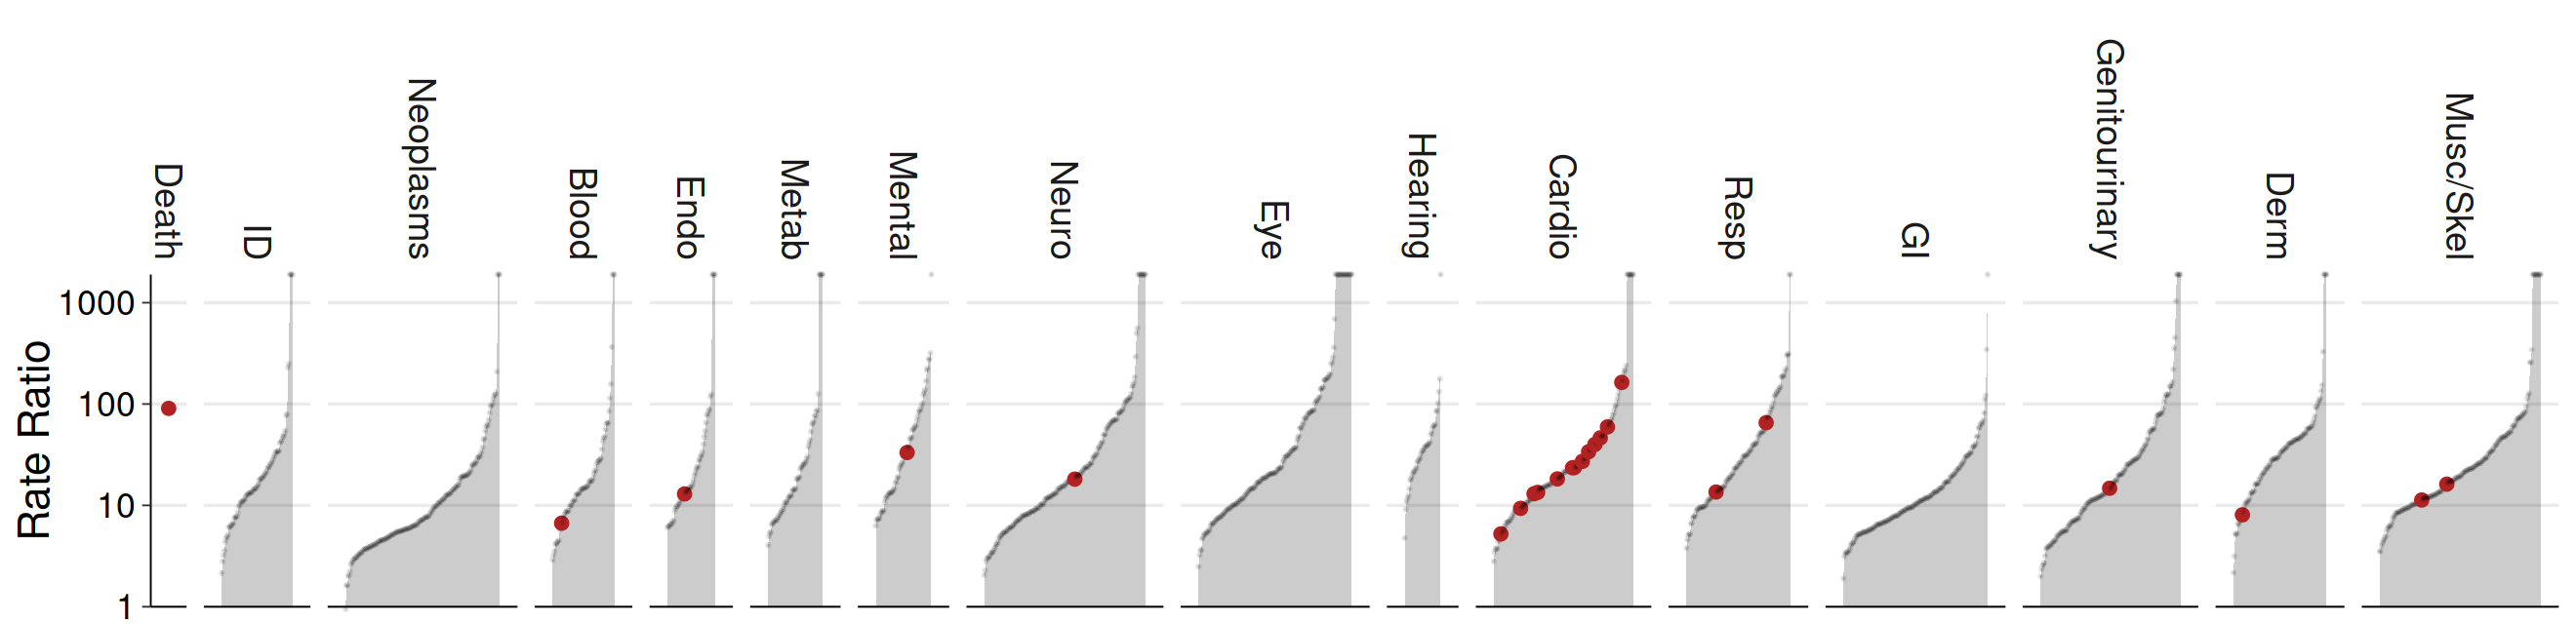

In [34]:
plot_width = 8.25; plot_height=2; plot_res = 320
options(repr.plot.width = plot_width, repr.plot.height = plot_height, repr.plot.res=plot_res)

library(ggtext)
categories_sorted = (endpoints_md %>% arrange(endpoint) %>% distinct(phecode_category) %>% as_tibble())$phecode_category

temp = ratio_df_complete %>%
    mutate(phecode_category = factor(phecode_category, levels=categories_sorted)) %>%
    mutate(highlight = case_when(endpoint %in% endpoint_selection ~ "YES", TRUE ~ "NO")) 
#+    mutate(score = factor(score, levels=scores_plot)) %>%
#+    mutate(endpoint = factor(endpoint, levels=endpoints_sorted)) %>%
#+    ungroup() %>%
#+    pivot_wider(names_from=score, values_from=cindex) %>% 
#+    mutate(id = row_number()) %>%
#+    mutate(delta = `Age+Sex+MedicalHistory`-`Age+Sex`) %>%
#+    group_by(endpoint, phecode_string, phecode_category) %>%
#+    summarise(delta = median(delta)) %>%
#+    mutate(pos = case_when(delta>=0 ~ "pos", delta < 0 ~"neg")) %>%
#+    mutate(endpoint = fct_reorder(endpoint, delta)) %>%
    # %>%# %>% filter(endpoint %in% endpoint_sample)
#+    

endpoint_order = (temp %>% arrange(ratio))$endpoint

temp = temp %>% mutate(endpoint = factor(endpoint, levels=endpoint_order)) %>% ungroup() %>% 
    arrange(endpoint) %>% group_by(phecode_category) %>% mutate(endpoint = row_number()) %>% mutate(log_ratio = log(ratio)) %>%
    filter(!phecode_category %in% c("Signs/Symptoms", "Preg", "Rx", "Stat"))

overview = ggplot(temp) +
    geom_ribbon(aes(x=endpoint, ymin=0, ymax=log_ratio), fill="black", alpha=0.2)+
    geom_point(aes(x=endpoint, y=log_ratio, color=highlight, size=highlight, alpha=highlight)) +
    #geom_text(data=temp %>% filter(highlight=="YES"), aes(x=endpoint, y=log_ratio+0.5, label="↓", vjust=0), color="black", size=5, alpha=0.7) +
    #geom_segment(aes(x=endpoint, xend=endpoint, y=0, yend=delta, color=highlight, size=highlight), alpha=0.5)+#+
    labs(x="Endpoints", y="Rate Ratio") +# (Top vs. Bottom 10%)")+
    scale_color_manual(values=c("NO"="black", "YES"="firebrick"))+
    scale_alpha_manual(values=c("NO"=0.1, "YES"=1))+
    scale_size_manual(values=c("NO"=0.01, "YES"=1))+
    #scale_colour_manual(values = c("pos"="forestgreen", "neg" = "firebrick")) + 
    #coord_polar() +
    coord_cartesian(ylim=c(0, NA), clip = "off")+
    scale_y_continuous(expand=c(0, 0), breaks=c(log(1), log(10), log(100), log(1000)), labels=c(1, 10, 100, 1000)) +
    #scale_y_continuous(, trans='log10')+
    scale_x_discrete(expand=expansion(add=20))+
    facet_grid(~phecode_category, scales="free_x", space="free_x")+#, switch=TRUE)+
    #facet_grid2(~phecode_category, scales = "free", independent = "all") + 
    theme(axis.title.x=element_blank(),
        axis.text.x=element_blank(),
        axis.ticks.x=element_blank(),
        panel.grid.major.y=element_line(), 
         strip.text = element_text(angle=270, hjust=1)) + 
    theme(legend.position="none") 
    
    #geom_ribbon(aes(x=id, ymin=AgeSex, ymax=`Age+Sex+MedicalHistory`), fill="red", alpha=0.2)
#geom_violin(size=0.1)
overview

In [35]:
library(gt)
plot_name = "Figure2a_overview"
overview %>% ggsave(filename=glue("outputs/{plot_name}.pdf"), device=cairo_pdf, width=plot_width, height=plot_height, dpi=plot_res)